# Cell 1: Setup & Imports

In [23]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import requests
import time
import gc

# Ensure GPU is available in Kaggle
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# Cell 2: Fetch Data & Create Pipeline

In [24]:
# 1. Download Tiny Shakespeare
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = requests.get(url).text

# 2. Build Vocabulary
chars = sorted(list(set(text)))
vocab_size = len(chars)
char2int = {ch: i for i, ch in enumerate(chars)}
int2char = {i: ch for i, ch in enumerate(chars)}

# Encode the entire text
encoded_text = np.array([char2int[ch] for ch in text])

# 3. Create PyTorch Dataset
class ShakespeareDataset(torch.utils.data.Dataset):
    def __init__(self, data, seq_length):
        self.data = data
        self.seq_length = seq_length

    def __len__(self):
        return len(self.data) - self.seq_length

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_length]
        y = self.data[idx + 1 : idx + self.seq_length + 1]
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)

# Configuration
SEQ_LENGTH = 300
BATCH_SIZE = 256 # High batch size to stress-test the GPU

# Use a subset of data for faster epoch iteration during benchmarking
train_data = encoded_text[:500000] 
dataset = ShakespeareDataset(train_data, SEQ_LENGTH)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

print(f"Vocab Size: {vocab_size} | Total Batches per Epoch: {len(dataloader)}")

Vocab Size: 65 | Total Batches per Epoch: 1951


# Cell 3: Architecture Engineering

In [25]:
class CustomRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.W = nn.Linear(embed_size + hidden_size, hidden_size)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        batch_size, seq_len = x.size()
        h = torch.zeros(batch_size, self.hidden_size).to(device)
        out_seq = []
        
        x_emb = self.embed(x)
        # Sequential Python Loop (The bottleneck we are testing)
        for t in range(seq_len):
            combined = torch.cat((x_emb[:, t, :], h), dim=1)
            h = torch.tanh(self.W(combined))
            out_seq.append(h.unsqueeze(1))
            
        out_seq = torch.cat(out_seq, dim=1)
        return self.fc(out_seq)

class CustomLSTM(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.embed = nn.Embedding(vocab_size, embed_size)
        # 4 Gates using nn.Linear
        self.W_i = nn.Linear(embed_size + hidden_size, hidden_size)
        self.W_f = nn.Linear(embed_size + hidden_size, hidden_size)
        self.W_c = nn.Linear(embed_size + hidden_size, hidden_size)
        self.W_o = nn.Linear(embed_size + hidden_size, hidden_size)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        batch_size, seq_len = x.size()
        h = torch.zeros(batch_size, self.hidden_size).to(device)
        c = torch.zeros(batch_size, self.hidden_size).to(device)
        out_seq = []
        
        x_emb = self.embed(x)
        for t in range(seq_len):
            combined = torch.cat((x_emb[:, t, :], h), dim=1)
            
            i = torch.sigmoid(self.W_i(combined))
            f = torch.sigmoid(self.W_f(combined))
            c_candidate = torch.tanh(self.W_c(combined))
            o = torch.sigmoid(self.W_o(combined))
            
            c = f * c + i * c_candidate
            h = o * torch.tanh(c)
            out_seq.append(h.unsqueeze(1))
            
        out_seq = torch.cat(out_seq, dim=1)
        return self.fc(out_seq)

class BuiltInLSTM(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        x_emb = self.embed(x)
        out, _ = self.lstm(x_emb) # Fused cuDNN backend execution
        return self.fc(out)

class BuiltInRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.RNN(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        x_emb = self.embed(x)
        out, _ = self.rnn(x_emb)
        return self.fc(out)

# Cell 4: The Benchmarking Engine

In [26]:
def train_and_benchmark(model, name, epochs=3):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    
    metrics = {'loss': [], 'time_per_epoch': []}
    
    print(f"\n--- Training {name} ---")
    torch.cuda.reset_peak_memory_stats()
    
    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        epoch_loss = 0
        
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            
            optimizer.zero_grad()
            outputs = model(x)
            # Reshape for CrossEntropy: (batch_size * seq_len, vocab_size)
            loss = criterion(outputs.view(-1, vocab_size), y.view(-1))
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            
        epoch_time = time.time() - start_time
        avg_loss = epoch_loss / len(dataloader)
        
        metrics['loss'].append(avg_loss)
        metrics['time_per_epoch'].append(epoch_time)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Time: {epoch_time:.2f}s")
        
    metrics['memory_mb'] = torch.cuda.max_memory_allocated() / (1024 ** 2)
    print(f"Peak GPU Memory: {metrics['memory_mb']:.2f} MB")
    

    torch.cuda.empty_cache()
    gc.collect()
    
    return metrics, model

# Hyperparameters
EMBED_SIZE = 64
HIDDEN_SIZE = 128
EPOCHS = 3

# Execute Benchmarks & Save All 4 Models
results = {}
trained_models = {}

print("--- Training All 4 Models (Seq Len: 300) ---")
# Warning: Since Seq Len is 300, the Custom (Python loop) models will take a few minutes!

# 1. Custom RNN
metrics, model = train_and_benchmark(CustomRNN(vocab_size, EMBED_SIZE, HIDDEN_SIZE), "Custom RNN", EPOCHS)
results['Custom RNN'] = metrics
trained_models['Custom RNN'] = model

# 2. Built-in RNN
metrics, model = train_and_benchmark(BuiltInRNN(vocab_size, EMBED_SIZE, HIDDEN_SIZE), "Built-in RNN", EPOCHS)
results['Built-in RNN'] = metrics
trained_models['Built-in RNN'] = model

# 3. Custom LSTM
metrics, model = train_and_benchmark(CustomLSTM(vocab_size, EMBED_SIZE, HIDDEN_SIZE), "Custom LSTM", EPOCHS)
results['Custom LSTM'] = metrics
trained_models['Custom LSTM'] = model

# 4. Built-in LSTM
metrics, model = train_and_benchmark(BuiltInLSTM(vocab_size, EMBED_SIZE, HIDDEN_SIZE), "Built-in LSTM", EPOCHS)
results['Built-in LSTM'] = metrics
trained_models['Built-in LSTM'] = model

--- Training All 4 Models (Seq Len: 300) ---

--- Training Custom RNN ---
Epoch 1/3 | Loss: 1.5148 | Time: 291.17s
Epoch 2/3 | Loss: 1.3909 | Time: 290.41s
Epoch 3/3 | Loss: 1.3793 | Time: 291.57s
Peak GPU Memory: 228.94 MB

--- Training Built-in RNN ---
Epoch 1/3 | Loss: 1.5183 | Time: 24.84s
Epoch 2/3 | Loss: 1.3917 | Time: 24.93s
Epoch 3/3 | Loss: 1.3797 | Time: 24.92s
Peak GPU Memory: 780.74 MB

--- Training Custom LSTM ---
Epoch 1/3 | Loss: 1.4109 | Time: 596.69s
Epoch 2/3 | Loss: 1.1831 | Time: 589.94s
Epoch 3/3 | Loss: 1.1527 | Time: 588.88s
Peak GPU Memory: 417.00 MB

--- Training Built-in LSTM ---
Epoch 1/3 | Loss: 1.4188 | Time: 64.55s
Epoch 2/3 | Loss: 1.1924 | Time: 64.76s
Epoch 3/3 | Loss: 1.1581 | Time: 64.55s
Peak GPU Memory: 1215.60 MB


# Cell 5: Plotting the Benchmarks

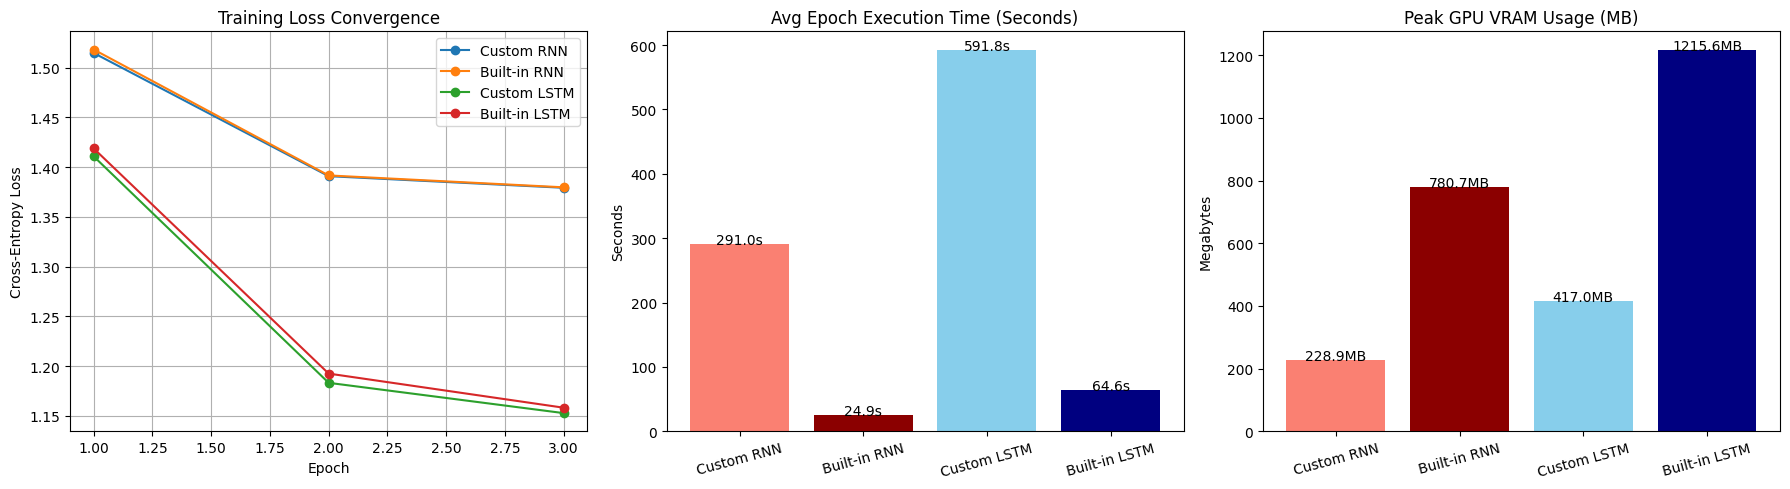

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Define 4 colors for our 4 models
# (Custom RNN, Built-in RNN, Custom LSTM, Built-in LSTM)
bar_colors = ['salmon', 'darkred', 'skyblue', 'navy']

# 1. Loss Convergence Curve (Accuracy Check)
for name, metrics in results.items():
    axes[0].plot(range(1, EPOCHS+1), metrics['loss'], label=name, marker='o')
axes[0].set_title('Training Loss Convergence')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True)

# 2. Average Training Speed (The Python loop vs cuDNN proof)
names = list(results.keys())
times = [np.mean(results[name]['time_per_epoch']) for name in names]
axes[1].bar(names, times, color=bar_colors)
axes[1].set_title('Avg Epoch Execution Time (Seconds)')
axes[1].set_ylabel('Seconds')
axes[1].tick_params(axis='x', rotation=15) # Slightly rotate labels so they fit
for i, v in enumerate(times):
    axes[1].text(i, v + 0.1, f"{v:.1f}s", ha='center')

# 3. VRAM Memory Footprint
memories = [results[name]['memory_mb'] for name in names]
axes[2].bar(names, memories, color=bar_colors)
axes[2].set_title('Peak GPU VRAM Usage (MB)')
axes[2].set_ylabel('Megabytes')
axes[2].tick_params(axis='x', rotation=15)
for i, v in enumerate(memories):
    axes[2].text(i, v + 0.1, f"{v:.1f}MB", ha='center')

plt.tight_layout()
plt.show()

# Cell 6: The Vanishing Gradient Proof

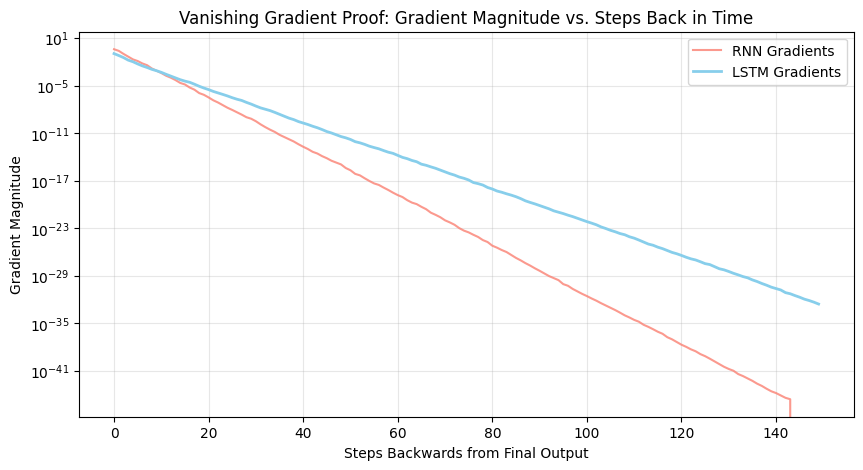

In [28]:
# Cell 6: The Vanishing Gradient Proof
# We use a long sequence to force the gradients to vanish
LONG_SEQ_LEN = 150

# Initialize native PyTorch layers for a mathematically clean test
test_rnn = nn.RNN(EMBED_SIZE, HIDDEN_SIZE, batch_first=True).to(device)
test_lstm = nn.LSTM(EMBED_SIZE, HIDDEN_SIZE, batch_first=True).to(device)

# FIX: Create tensor directly on the device so it remains a "leaf" tensor
x_test = torch.randn(1, LONG_SEQ_LEN, EMBED_SIZE, device=device, requires_grad=True)

# --- RNN Gradient Check ---
out_rnn, _ = test_rnn(x_test)
# We only calculate "loss" based on the VERY LAST time step
loss_rnn = out_rnn[:, -1, :].sum()
loss_rnn.backward()
# Extract the gradient magnitudes across the sequence dimension
grad_rnn = x_test.grad.abs().mean(dim=-1).squeeze().cpu().numpy()

# Reset gradients for the next test
x_test.grad.zero_()

# --- LSTM Gradient Check ---
out_lstm, _ = test_lstm(x_test)
# Calculate loss based on the VERY LAST time step again
loss_lstm = out_lstm[:, -1, :].sum()
loss_lstm.backward()
# Extract the gradient magnitudes
grad_lstm = x_test.grad.abs().mean(dim=-1).squeeze().cpu().numpy()

# --- Plotting ---
plt.figure(figsize=(10, 5))
# Plotting backwards so x-axis represents "distance from the final output"
plt.plot(grad_rnn[::-1], label='RNN Gradients', color='salmon', alpha=0.8)
plt.plot(grad_lstm[::-1], label='LSTM Gradients', color='skyblue', linewidth=2)

plt.title('Vanishing Gradient Proof: Gradient Magnitude vs. Steps Back in Time')
plt.xlabel('Steps Backwards from Final Output')
plt.ylabel('Gradient Magnitude')
plt.yscale('log') # Log scale makes the exponential decay visually obvious
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [29]:
# Cell 7: Generating Text Across All 4 Models
import torch.nn.functional as F

def generate_text(model, start_string="O Romeo, Romeo!\n", gen_length=200, temperature=0.75):
    model.eval() # Put model in evaluation mode
    
    # Convert starting string to tensor
    input_chars = [char2int[c] for c in start_string]
    input_seq = torch.tensor(input_chars, dtype=torch.long).unsqueeze(0).to(device)
    
    generated_text = start_string
    
    with torch.no_grad():
        for _ in range(gen_length):
            output = model(input_seq)
            logits = output[0, -1, :] 
            probs = F.softmax(logits / temperature, dim=0)
            
            next_char_idx = torch.multinomial(probs, num_samples=1).item()
            generated_text += int2char[next_char_idx]
            
            next_char_tensor = torch.tensor([[next_char_idx]], dtype=torch.long).to(device)
            input_seq = torch.cat((input_seq, next_char_tensor), dim=1)
            
    return generated_text


# --- Execute Generation for All Models ---
START_PROMPT = "O Romeo, Romeo!\n"

print(f"--- GENERATING TEXT FOR ALL MODELS ---\n")

for model_name, model in trained_models.items():
    print("=" * 60)
    print(f"  MODEL: {model_name.upper()}")
    print("=" * 60)
    
    try:
        output_text = generate_text(model, start_string=START_PROMPT, gen_length=200)
        print(output_text)
    except Exception as e:
        print(f"Error generating text for {model_name}: {e}")
        
    print("\n")

--- GENERATING TEXT FOR ALL MODELS ---

  MODEL: CUSTOM RNN
O Romeo, Romeo!

KING RICHARD III:
And for the king not commends alone to your traitor.

Nurse:
That with the fair royal banished, my lord, thou darces the boy!

JULIET:
Oursh soul
And sick the voicer:
The curses us 


  MODEL: BUILT-IN RNN
O Romeo, Romeo!
Shall I am never prosed with him.

LARTIUS:
And not despaim and my lord in another how where loather this than you hath seen the gods,
The will do fastle brother'd hand that sleep at the king's noble 


  MODEL: CUSTOM LSTM
O Romeo, Romeo!

QUEEN MARGARET:
To my keeps face and leads, wherein do
hath spirit the service of poor consel,
But so very kind of time and the senate,
Were upon this state, that is a planised to my courst of good
T


  MODEL: BUILT-IN LSTM
O Romeo, Romeo!

AUFIDIUS:
Besingly shall do I think, so, then
Will you go in war from where he wounded,
And save a traitor, to entercesish'd!

CORIOLANUS:
She kings, servilt is blow of mean.

VIRGILIA:
Nay, he is ba
